In [1]:
# imports
import snntorch as snn
from snntorch import surrogate
from snntorch import backprop
from snntorch import functional as SF
from snntorch import utils
from snntorch import spikeplot as splt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.nn.functional as F

import matplotlib.pyplot as plt
import numpy as np
import itertools

C:\Users\nb0801\AppData\Local\Temp\ipykernel_13680\3569606770.py:4: DeprecationWarning: The module snntorch.backprop will be deprecated in  a future release. Writing out your own training loop will lead to substantially faster performance.
  from snntorch import backprop


In [2]:
# Leaky neuron model, overriding the backward pass with a custom function
class LeakySigmoidSurrogate(nn.Module):
  def __init__(self, beta, threshold=1.0, k=25):

      # Leaky_Surrogate is defined in the previous tutorial and not used here
      super(Leaky_Surrogate, self).__init__()

      # initialize decay rate beta and threshold
      self.beta = beta
      self.threshold = threshold
      self.surrogate_func = self.FastSigmoid.apply

  # the forward function is called each time we call Leaky
  def forward(self, input_, mem):
    spk = self.surrogate_func((mem-self.threshold))  # call the Heaviside function
    reset = (spk - self.threshold).detach()
    mem = self.beta * mem + input_ - reset
    return spk, mem

  # Forward pass: Heaviside function
  # Backward pass: Override Dirac Delta with gradient of fast sigmoid
  @staticmethod
  class FastSigmoid(torch.autograd.Function):
    @staticmethod
    def forward(ctx, mem, k=25):
        ctx.save_for_backward(mem) # store the membrane potential for use in the backward pass
        ctx.k = k
        out = (mem > 0).float() # Heaviside on the forward pass: Eq(1)
        return out

    @staticmethod
    def backward(ctx, grad_output):
        (mem,) = ctx.saved_tensors  # retrieve membrane potential
        grad_input = grad_output.clone()
        grad = grad_input / (ctx.k * torch.abs(mem) + 1.0) ** 2  # gradient of fast sigmoid on backward pass: Eq(4)
        return grad, None

Better yet, all of that can be condensed by using the built-in module `snn.surrogate` from snnTorch, where $k$ from $(4)$ is denoted `slope`. The surrogate gradient is passed into `spike_grad` as an argument:

In [3]:
spike_grad = surrogate.fast_sigmoid(slope=25)
beta = 0.5

lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad)

To explore the other surrogate gradient functions available, [take a look at the documentation here.](https://snntorch.readthedocs.io/en/latest/snntorch.surrogate.html)

# 2. Setting up the CSNN
## 2.1 DataLoaders

In [4]:
# dataloader arguments
batch_size = 128
data_path='/tmp/data/mnist'

dtype = torch.int8
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [5]:
folder_path = r"C:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\saved_data\ROAD"

int_id_data = np.load(folder_path + r"\int_id_data.npy", allow_pickle=True)
attack_labels = np.load(folder_path + r"\attack_labels.npy", allow_pickle=True)


int_id_data_test = np.load(folder_path + r"\int_id_data_test.npy", allow_pickle=True)
attack_labels_test = np.load(folder_path + r"\attack_labels_test.npy", allow_pickle=True)

In [6]:
def uint8_to_bit_arrays(data_list):
    return [np.unpackbits(np.asarray(arr, dtype=np.uint8), axis=-1)
            for arr in data_list]

int_id_data_bin = uint8_to_bit_arrays(int_id_data)
int_id_data_test_bin = uint8_to_bit_arrays(int_id_data_test)

print(int_id_data_bin[0].shape)
print(int_id_data_test_bin[0].shape)

(41580, 80)
(10394, 80)


In [7]:
import builtins
import numpy as np


def sliding_windows_id_data(samples, labels, window_size=32, step=2, attack_labels=('T', 'D', 'F', 'S')):
    n = len(samples)

    if isinstance(attack_labels, str):
        attack_labels = (attack_labels,)

    windows = []
    window_labels = []
    next_id_datas = []
    

    for start in range(0, n - window_size, step):
        end = start + window_size
        window_slice = labels[start:end]

        windows.append(samples[start:end])
        next_id_datas.append(samples[end])

        matching_attack = builtins.next(
            (label for label in attack_labels if label in window_slice),
            'R'
        )
        window_labels.append(matching_attack)

    return (
        np.array(windows, dtype=np.uint8),
        np.array(next_id_datas, dtype=object),
        np.array(window_labels, dtype=object)
    )

windows, windowed_labels = [], []
for i in range(len(int_id_data)):
    windows_batch, next_values, windowed_labels_batch = sliding_windows_id_data(int_id_data_bin[i], attack_labels[i])
    windows.extend(windows_batch)
    windowed_labels.extend(windowed_labels_batch)

windowed_labels = np.array(windowed_labels)
attack_onehot = np.zeros((len(windowed_labels), 2), dtype=np.uint8)
attack_onehot[windowed_labels == 'R', 0] = 1
attack_onehot[windowed_labels == 'T', 1] = 1

print(attack_onehot[:10])

windows_test, windowed_labels_test = [], []
for i in range(len(int_id_data)):
    windows_batch, next_values, windowed_labels_batch = sliding_windows_id_data(int_id_data_test_bin[i], attack_labels_test[i])
    windows_test.extend(windows_batch)
    windowed_labels_test.extend(windowed_labels_batch)

windowed_labels_test = np.array(windowed_labels_test)

attack_onehot_test = np.zeros((len(windowed_labels_test), 2), dtype=np.uint8)
attack_onehot_test[windowed_labels_test == 'R', 0] = 1
attack_onehot_test[windowed_labels_test == 'T', 1] = 1

print(attack_onehot_test[:10])


[[1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [0 1]
 [0 1]
 [0 1]
 [0 1]]
[[0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [1 0]
 [0 1]
 [0 1]
 [0 1]]


In [8]:
windows = np.array(windows)
windows_test = np.array(windows_test)

windowed_labels = np.array(windowed_labels)
windowed_labels_test = np.array(windowed_labels_test)

In [9]:
windows.shape

(2229345, 32, 80)

In [10]:
import numpy as np

# Fraction of the data to keep
keep_fraction = 1  # Keep 20%, remove 80%

# For reproducibility
np.random.seed(42)

# Number of samples to keep
num_keep = int(len(windows) * keep_fraction)

# Random indices
indices = np.random.choice(len(windows), size=num_keep, replace=False)

# Optional: sort indices (keeps original order)
indices = np.sort(indices)

# Keep only the selected samples
windows = windows[indices]
windowed_labels = windowed_labels[indices]

print(windows.shape)
print(windowed_labels.shape)

(2229345, 32, 80)
(2229345,)


In [11]:
import numpy as np

label_map = {
    'R': 0,
    'T': 1
}

windowed_labels = np.array(
    [label_map[label] for label in windowed_labels],
    dtype=np.int64
)

windowed_labels_test = np.array(
    [label_map[label] for label in windowed_labels_test],
    dtype=np.int64
)

In [12]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train = torch.tensor(windows, dtype=torch.float).unsqueeze(1)
y_train = torch.tensor(windowed_labels, dtype=torch.long)

X_test = torch.tensor(windows_test, dtype=torch.float).unsqueeze(1)
y_test = torch.tensor(windowed_labels_test, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False
)

## 2.2 Define the Network

The convolutional network architecture to be used is: 12C5-MP2-64C5-MP2-1024FC10

- 12C5 is a 5$\times$5 convolutional kernel with 12 filters
- MP2 is a 2$\times$2 max-pooling function
- 1024FC10 is a fully-connected layer that maps 1,024 neurons to 10 outputs

In [13]:
# neuron and simulation parameters
spike_grad = surrogate.fast_sigmoid(slope=25)
beta = 0.5
num_steps = 15

In [14]:
# Define Network
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        # Initialize layers
        self.conv1 = nn.Conv2d(1, 12, 5)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.conv2 = nn.Conv2d(12, 64, 5)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.fc1 = nn.Linear(64*4*4, 10)
        self.lif3 = snn.Leaky(beta=beta, spike_grad=spike_grad)

    def forward(self, x):

        # Initialize hidden states and outputs at t=0
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()

        cur1 = F.max_pool2d(self.conv1(x), 2)
        spk1, mem1 = self.lif1(cur1, mem1)

        cur2 = F.max_pool2d(self.conv2(spk1), 2)
        spk2, mem2 = self.lif2(cur2, mem2)

        cur3 = self.fc1(spk2.view(batch_size, -1))
        spk3, mem3 = self.lif3(cur3, mem3)
        return spk3, mem3

In the previous tutorial, the network was wrapped inside of a class, as shown above.
With increasing network complexity, this adds a lot of boilerplate code that we might wish to avoid. Alternatively, the `nn.Sequential` method can be used instead.

> Note: the following code-block simulates over one single time-step, and requires a separate for-loop over time.

In [15]:
net = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=(24, 24)),
    nn.MaxPool2d(2),
    snn.Leaky(
        beta=beta,
        spike_grad=spike_grad,
        init_hidden=True
    ),

    nn.Conv2d(32, 64, kernel_size=3),
    nn.MaxPool2d(2),
    snn.Leaky(
        beta=beta,
        spike_grad=spike_grad,
        init_hidden=True
    ),

    nn.Flatten(),

    nn.Linear(64 * 1 * 13, 2),

    snn.Leaky(
        beta=beta,
        spike_grad=spike_grad,
        init_hidden=True,
        output=True
    )
).to(device)


The `init_hidden` argument initializes the hidden states of the neuron (here, membrane potential). This takes place in the background as an instance variable.
If `init_hidden` is activated, the membrane potential is not explicitly returned to the user, ensuring only the output spikes are sequentially passed through the layers wrapped in `nn.Sequential`.

To train a model using the final layer's membrane potential, set the argument `output=True`.
This enables the final layer to return both the spike and membrane potential response of the neuron.

## 2.3 Forward-Pass
A forward pass across a simulation duration of `num_steps` looks like this:

In [16]:
data, targets = next(iter(train_loader))
data = data.to(device)
targets = targets.to(device)

for step in range(num_steps):
    spk_out, mem_out = net(data)

print(data.shape)
print(spk_out.shape)
print(mem_out)

torch.Size([128, 1, 32, 80])
torch.Size([128, 2])
tensor([[0.0268, 0.0655],
        [0.0268, 0.0655],
        [0.0268, 0.0655],
        [0.0268, 0.0655],
        [0.0268, 0.0655],
        [0.0268, 0.0655],
        [0.0268, 0.0655],
        [0.0268, 0.0655],
        [0.0268, 0.0655],
        [0.0268, 0.0655],
        [0.0268, 0.0655],
        [0.0268, 0.0655],
        [0.0268, 0.0655],
        [0.0268, 0.0655],
        [0.0268, 0.0655],
        [0.0268, 0.0655],
        [0.0268, 0.0655],
        [0.0268, 0.0655],
        [0.0268, 0.0655],
        [0.0268, 0.0655],
        [0.0268, 0.0655],
        [0.0268, 0.0655],
        [0.0268, 0.0655],
        [0.0268, 0.0655],
        [0.0268, 0.0655],
        [0.0268, 0.0655],
        [0.0268, 0.0655],
        [0.0268, 0.0655],
        [0.0268, 0.0655],
        [0.0268, 0.0655],
        [0.0268, 0.0655],
        [0.0268, 0.0655],
        [0.0268, 0.0655],
        [0.0268, 0.0655],
        [0.0268, 0.0655],
        [0.0268, 0.0655],
        [0.026

Wrap that in a function, recording the membrane potential and spike response over time:

In [17]:
def forward_pass(net, num_steps, data):
  mem_rec = []
  spk_rec = []
  utils.reset(net)  # resets hidden states for all LIF neurons in net

  for step in range(num_steps):
      spk_out, mem_out = net(data)
      spk_rec.append(spk_out)
      mem_rec.append(mem_out)

  return torch.stack(spk_rec), torch.stack(mem_rec)

In [18]:
spk_rec, mem_rec = forward_pass(net, num_steps, data)

# 3. Training Loop

## 3.1 Loss Using snn.Functional

In the previous tutorial, the Cross Entropy Loss between the membrane potential of the output neurons and the target was used to train the network.
This time, the total number of spikes from each neuron will be used to calculate the Cross Entropy instead.

A variety of loss functions are included in the `snn.functional` module, which is analogous to `torch.nn.functional` in PyTorch.
These implement a mix of cross entropy and mean square error losses, are applied to spikes and/or membrane potential, to train a rate or latency-coded network.

The approach below applies the cross entropy loss to the output spike count in order train a rate-coded network:

In [19]:
# already imported snntorch.functional as SF
loss_fn = SF.ce_rate_loss()

The recordings of the spike are passed as the first argument to `loss_fn`, and the target neuron index as the second argument to generate a loss. [The documentation provides further information and exmaples.](https://snntorch.readthedocs.io/en/latest/snntorch.functional.html#snntorch.functional.ce_rate_loss)

In [20]:
loss_val = loss_fn(spk_rec, targets)

print(f"The loss from an untrained network is {loss_val.item():.3f}")

The loss from an untrained network is 0.693


## 3.2 Accuracy Using snn.Functional
The `SF.accuracy_rate()` function works similarly, in that the predicted output spikes and actual targets are supplied as arguments. `accuracy_rate` assumes a rate code is used to interpret the output by checking if the index of the neuron with the highest spike count matches the target index.

In [21]:
acc = SF.accuracy_rate(spk_rec, targets)

print(f"The accuracy of a single batch using an untrained network is {acc*100:.3f}%")

The accuracy of a single batch using an untrained network is 71.094%


As the above function only returns the accuracy of a single batch of data, the following function returns the accuracy on the entire DataLoader object:

In [22]:
def batch_accuracy(train_loader, net, num_steps):
  with torch.no_grad():
    total = 0
    acc = 0
    net.eval()

    train_loader = iter(train_loader)
    for data, targets in train_loader:
      data = data.to(device)
      targets = targets.to(device)
      spk_rec, _ = forward_pass(net, num_steps, data)

      acc += SF.accuracy_rate(spk_rec, targets) * spk_rec.size(1)
      total += spk_rec.size(1)

  return acc/total

In [21]:
test_acc = batch_accuracy(test_loader, net, num_steps)

print(f"The total accuracy on the test set is: {test_acc * 100:.2f}%")

KeyboardInterrupt: 

## 3.3 Training Loop

The following training loop is qualitatively similar to the previous tutorial.

In [23]:
for data, targets in train_loader:
    print(data.shape)
    print(targets.shape)
    break

torch.Size([128, 1, 32, 80])
torch.Size([128])


In [29]:
optimizer = torch.optim.Adam(net.parameters(), lr=5e-4)#, betas=(0.9, 0.999))
num_epochs = 1
loss_hist = []
test_acc_hist = []
counter = 0

# Outer training loop
for epoch in range(num_epochs):

    # Training loop
    for data, targets in iter(train_loader):
        data = data.to(device)
        targets = targets.to(device)

        # forward pass
        net.train()
        spk_rec, _ = forward_pass(net, num_steps, data)

        # initialize the loss & sum over time
        loss_val = loss_fn(spk_rec, targets)

        # Gradient calculation + weight update
        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()

        # Store loss history for future plotting
        loss_hist.append(loss_val.item())

        # Test set
        if counter % 50 == 0:
#            print(f"counter : {counter}")
#            acc = SF.accuracy_rate(spk_rec, targets)
#
#            print(f"The accuracy of a single batch using an untrained network is {acc*100:.3f}%")
#            test_acc_hist.append(acc)
          with torch.no_grad():
              net.eval()

              # Test set forward pass
              test_acc = batch_accuracy(test_loader, net, num_steps)
              print(f"Iteration {counter}, Test Acc: {test_acc * 100:.2f}%\n")
              test_acc_hist.append(test_acc.item())

        counter += 1

KeyboardInterrupt: 

Despite having selected some fairly generic values and architectures, the test set accuracy should be fairly competitive given the brief training run!

# 4. Results
## 4.1 Plot Test Accuracy

In [ ]:
acc = SF.accuracy_rate(spk_rec, targets)

print(f"The accuracy of a single batch using an untrained network is {acc*100:.3f}%")

The accuracy of a single batch using an untrained network is 95.312%


: 

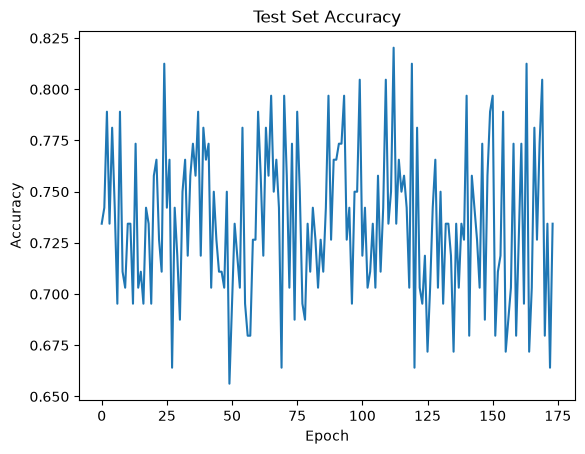

In [25]:
# Plot Loss
fig = plt.figure(facecolor="w")
plt.plot(test_acc_hist)
plt.title("Test Set Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

## 4.2 Spike Counter

Run a forward pass on a batch of data to obtain spike and membrane readings.

In [26]:
spk_rec, mem_rec = forward_pass(net, num_steps, data)

Changing `idx` allows you to index into various samples from the simulated minibatch. Use `splt.spike_count` to explore the spiking behaviour of a few different samples!

> Note: if you are running the notebook locally on your desktop, please uncomment the line below and modify the path to your ffmpeg.exe



The target label is: 0


findfont: Failed to find font weight black, now using 700.


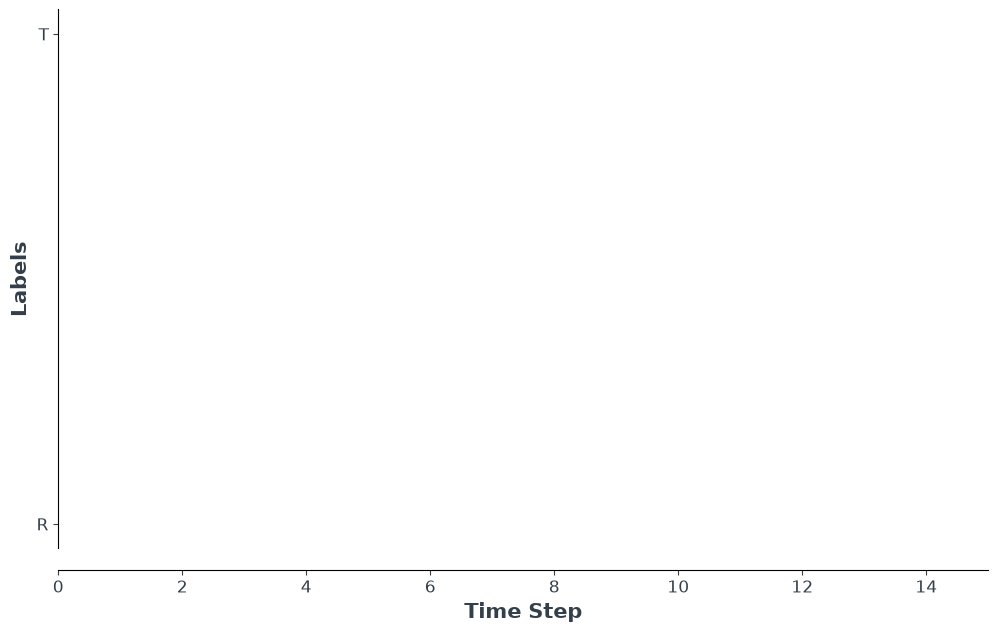

In [27]:
from IPython.display import HTML

idx = 0

fig, ax = plt.subplots(facecolor='w', figsize=(12, 7))
labels=['R', 'T']
print(f"The target label is: {targets[idx]}")

# plt.rcParams['animation.ffmpeg_path'] = 'C:\\path\\to\\your\\ffmpeg.exe'

#  Plot spike count histogram
anim = splt.spike_count(spk_rec[:, idx].detach().cpu(), fig, ax, labels=labels,
                        animate=True, interpolate=4)

HTML(anim.to_jshtml())
# anim.save("spike_bar.mp4")

# Conclusion
You should now have a grasp of the basic features of snnTorch and be able to start running your own experiments. [In the next tutorial](https://snntorch.readthedocs.io/en/latest/tutorials/index.html), we will train a network using a neuromorphic dataset.

A special thanks to [Gianfrancesco Angelini](https://github.com/gianfa) for providing valuable feedback on the tutorial.

If you like this project, please consider starring ⭐ the repo on GitHub as it is the easiest and best way to support it.

# Additional Resources
* [Check out the snnTorch GitHub project here.](https://github.com/jeshraghian/snntorch)